# Kelmarsh 2016 Wind Farm Data Validation and Exploratory Analysis

## Purpose

In this notebook we validate and explore the 2016 Kelmarsh Wind Farm SCADA and
status-event data. The main purpose here is to determine whether the dataset can support an evidence-grounded wind-turbine performance investigation copilot.

The 2016 data is used as the initial development year. After the file structure,
data quality, operational variables, and event records are understood, the
validated approach will be extended to the available 2016–2022 data.

## Main Questions

1. Are the SCADA and status files complete, consistent, and readable?
2. Which measurements are sufficiently available and relevant to turbine
   performance investigation?
3. What do wind conditions, actual power, potential power, availability, and recorded losses reveal in the Turbine 1 sample?
4. Can status events be aligned with SCADA measurements?
5. Does the 2016 data contain credible turbine-underperformance periods for a
   detailed investigation?

## Scope

This notebook inventories all six 2016 turbine exports and validates their SCADA schema consistency. Detailed data-quality analysis, performance EDA, status-event alignment, and investigation-case development focus primarily on Turbine 1 as a manageable development sample.

The resulting data contract is provisional. Cross-turbine and cross-year validation will be performed in the next project phase before the reusable production pipeline is finalized.

## 1. Setup

This section imports the libraries used throughout the notebook.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Locate and Inventory the 2016 Data

Before loading hundreds of megabytes of SCADA data, we first locate the raw-data directory and inventory its files.

This step verifies that:

- the notebook can find the project directory;
- the expected raw-data directory exists;
- all six turbine SCADA files are available;
- all six turbine status-event files are available.

The filenames are collected programmatically instead of being entered manually, making the workflow easier to reproduce and extend.

In [2]:
current_directory = Path.cwd()
project_root = (
    current_directory.parent
    if current_directory.name == "notebooks"
    else current_directory
)

data_directory = project_root / "data" / "raw" / "kelmarsh_2016"

scada_files = sorted(data_directory.glob("Turbine_Data_*.csv"))
status_files = sorted(data_directory.glob("Status_*.csv"))

expected_turbines = 6

assert data_directory.is_dir(), "The 2016 raw-data directory was not found."
assert len(scada_files) == expected_turbines, (
    f"Expected {expected_turbines} SCADA files, found {len(scada_files)}."
)
assert len(status_files) == expected_turbines, (
    f"Expected {expected_turbines} status files, found {len(status_files)}."
)

print(f"Project root: {project_root}")
print(f"Data directory exists: {data_directory.exists()}")
print(f"SCADA files found: {len(scada_files)}")
print(f"Status files found: {len(status_files)}")

Project root: D:\Portfolio Projects\wind-farm-investigation-copilot
Data directory exists: True
SCADA files found: 6
Status files found: 6


In [3]:
print("SCADA files:")
for path in scada_files:
    print(f"  - {path.name}")

print("\nStatus files:")
for path in status_files:
    print(f"  - {path.name}")

SCADA files:
  - Turbine_Data_Kelmarsh_1_2016-01-03_-_2017-01-01_228.csv
  - Turbine_Data_Kelmarsh_2_2016-01-03_-_2017-01-01_229.csv
  - Turbine_Data_Kelmarsh_3_2016-01-03_-_2017-01-01_230.csv
  - Turbine_Data_Kelmarsh_4_2016-01-03_-_2017-01-01_231.csv
  - Turbine_Data_Kelmarsh_5_2016-01-03_-_2017-01-01_232.csv
  - Turbine_Data_Kelmarsh_6_2016-01-03_-_2017-01-01_233.csv

Status files:
  - Status_Kelmarsh_1_2016-01-03_-_2017-01-01_228.csv
  - Status_Kelmarsh_2_2016-01-03_-_2017-01-01_229.csv
  - Status_Kelmarsh_3_2016-01-03_-_2017-01-01_230.csv
  - Status_Kelmarsh_4_2016-01-03_-_2017-01-01_231.csv
  - Status_Kelmarsh_5_2016-01-03_-_2017-01-01_232.csv
  - Status_Kelmarsh_6_2016-01-03_-_2017-01-01_233.csv


## 3. Inspect the Raw SCADA File Structure

Before using `pandas`, we inspect a small number of lines from one SCADA file as plain text. This reveals where the metadata, column names, and observations begin without loading the approximately 90 MB file into memory.

Because all six SCADA files were exported by the same system, we begin with one representative file. Later, we will verify that the discovered structure is consistent across every turbine file.

In [4]:
sample_scada_path = scada_files[0]

with open(
    sample_scada_path,
    mode="r",
    encoding="utf-8",
    errors="replace",
) as file:
    for line_number, line in enumerate(file, start=1):
        print(f"{line_number}: {line.rstrip()}")

        if line_number == 12:
            break

1: # This file was exported by Greenbyte at 2022-01-27 10:33:05. Please see https://www.greenbyte.com for more information about Greenbyte.
2: #
3: # Turbine: Kelmarsh 1
4: # Turbine type: Senvion MM92
5: # Time zone: UTC
6: # Time interval: 2016-01-01 00:00:00 - 2017-01-01 00:00:00 (366 days)
7: #
8: # Data that is missing or is erroneous has been marked with the value "NaN"
9: #
10: # Date and time,Wind speed (m/s),"Wind speed, Standard deviation (m/s)","Wind speed, Minimum (m/s)","Wind speed, Maximum (m/s)",Long Term Wind (m/s),Wind speed Sensor 1 (m/s),"Wind speed Sensor 1, Standard deviation (m/s)","Wind speed Sensor 1, Minimum (m/s)","Wind speed Sensor 1, Maximum (m/s)",Wind speed Sensor 2 (m/s),"Wind speed Sensor 2, Standard deviation (m/s)","Wind speed Sensor 2, Minimum (m/s)","Wind speed Sensor 2, Maximum (m/s)",Density adjusted wind speed (m/s),Wind direction (°),Nacelle position (°),"Wind direction, Standard deviation (°)","Wind direction, Minimum (°)","Wind direction, Maxim

### Findings from the Raw SCADA File

The raw-file inspection reveals the following structure:

- Lines 1–9 contain export and turbine metadata.
- Line 10 contains the comma-separated column names.
- Observations begin on line 11 and use ten-minute timestamps.
- Missing or erroneous measurements are represented by `NaN`.
- The timestamp column is named `# Date and time`.

Therefore, the SCADA files must be loaded with `skiprows=9`. Using `comment="#"` would be incorrect because it would also remove the actual header row.

The metadata states that the requested period begins on 2016-01-01, while the first visible observation begins on 2016-01-03. We will test the temporal coverage of every turbine after loading the data.

### 3.1 Validate the SCADA Schema Across Turbines

The first SCADA file showed us how the export is structured, but a reusable loading process requires all six turbine files to have the same columns in the same order.

We load only the header of each file using `nrows=0`. This is faster and more memory-efficient than loading all observations merely to compare schemas.

In [5]:
reference_columns = pd.read_csv(
    scada_files[0],
    skiprows=9,
    nrows=0,
).columns.tolist()

for turbine_number, path in enumerate(scada_files, start=1):
    columns = pd.read_csv(
        path,
        skiprows=9,
        nrows=0,
    ).columns.tolist()

    matches_reference = columns == reference_columns

    print(
        f"Turbine {turbine_number}: "
        f"{len(columns)} columns | "
        f"matches reference: {matches_reference}"
    )

    assert matches_reference, (
        f"SCADA schema mismatch found in {path.name}"
    )

assert reference_columns[0] == "# Date and time"

Turbine 1: 299 columns | matches reference: True
Turbine 2: 299 columns | matches reference: True
Turbine 3: 299 columns | matches reference: True
Turbine 4: 299 columns | matches reference: True
Turbine 5: 299 columns | matches reference: True
Turbine 6: 299 columns | matches reference: True


## 4. Loading the Complete Sample SCADA Dataset

After making sure that all 6 turbines follow the same structure, we now load the complete SCADA dataset for one turbine. At this stage, all 299 columns are retained so we can do variable selection based on actual schema and data-quality.

The timestamp column is parsed during loading, allowing temporal coverage and measurement frequency to be validated correctly.

In [6]:
turbine_1 = pd.read_csv(scada_files[0], skiprows=9, parse_dates=["# Date and time"])

turbine_1 = turbine_1.rename(columns={"# Date and time": "Date and time"})

print("Shape:", turbine_1.shape)
print("Timestamp type:", turbine_1["Date and time"].dtype)
turbine_1.head()

Shape: (52416, 299)
Timestamp type: datetime64[ns]


,Date and time,Wind speed (m/s),"Wind speed, Standard deviation (m/s)","Wind speed, Minimum (m/s)","Wind speed, Maximum (m/s)",Long Term Wind (m/s),Wind speed Sensor 1 (m/s),"Wind speed Sensor 1, Standard deviation (m/s)","Wind speed Sensor 1, Minimum (m/s)","Wind speed Sensor 1, Maximum (m/s)",...,Tower Acceleration y (mm/ss),"Tower Acceleration X, Min (mm/ss)","Tower Acceleration X, Max (mm/ss)","Tower Acceleration Y, Min (mm/ss)","Tower Acceleration Y, Max (mm/ss)","Drive train acceleration, Max (mm/ss)","Drive train acceleration, Min (mm/ss)","Drive train acceleration, StdDev (mm/ss)","Tower Acceleration X, StdDev (mm/ss)","Tower Acceleration Y, StdDev (mm/ss)"
0,2016-01-03 00:00:00,NaN,NaN,NaN,NaN,7.1,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2016-01-03 00:10:00,NaN,NaN,NaN,NaN,7.1,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2016-01-03 00:20:00,NaN,NaN,NaN,NaN,7.1,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2016-01-03 00:30:00,NaN,NaN,NaN,NaN,7.1,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2016-01-03 00:40:00,NaN,NaN,NaN,NaN,7.1,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 4.1 Validate Temporal Coverage

Before analysing turbine measurements, we validate the time index. A reliable time series should have valid, unique timestamps and a consistent measurement interval.

We examine the start and end dates, missing and duplicate timestamps, and the frequency of differences between consecutive observations.

In [7]:
timestamps = turbine_1["Date and time"]

earliest = timestamps.min()
latest = timestamps.max()

duplicate_time = timestamps.duplicated().sum()
intervals = timestamps.diff()

missing_time = timestamps.isna().sum()

print("Earliest registered time: ", earliest)
print("Latest registered time: ", latest)

print("Missing time: ", missing_time)
print("Duplicate time: ", duplicate_time)

print("Frequency of each interval: ", intervals.value_counts())

Earliest registered time:  2016-01-03 00:00:00
Latest registered time:  2016-12-31 23:50:00
Missing time:  0
Duplicate time:  0
Frequency of each interval:  Date and time
0 days 00:10:00    52415
Name: count, dtype: int64


### 4.2 Compare Observed and Expected Timestamps

A dataset can contain no null timestamps while still omitting entire time intervals. We therefore construct the complete ten-minute schedule described by the metadata and compare it with the observed timestamps.

In [8]:
expected_timestamps = pd.date_range(
    start="2016-01-01 00:00:00",
    end="2017-01-01 00:00:00",
    freq="10min",
    inclusive="left",
)

print("Expected timestamp count:", len(expected_timestamps))
print("First expected timestamp:", expected_timestamps.min())
print("Last expected timestamp:", expected_timestamps.max())

Expected timestamp count: 52704
First expected timestamp: 2016-01-01 00:00:00
Last expected timestamp: 2016-12-31 23:50:00


In [9]:
observed_timestamps = pd.DatetimeIndex(timestamps)

absent_timestamps = expected_timestamps.difference(observed_timestamps)

print("Observed timestamp count:", len(observed_timestamps))
print("Absent timestamp count:", len(absent_timestamps))
print("First absent timestamp:", absent_timestamps.min())
print("Last absent timestamp:", absent_timestamps.max())

Observed timestamp count: 52416
Absent timestamp count: 288
First absent timestamp: 2016-01-01 00:00:00
Last absent timestamp: 2016-01-02 23:50:00


### Temporal Coverage Findings

The Turbine 1 SCADA dataset contains 52,416 observations covering the period from 2016-01-03 00:00 to 2016-12-31 23:50.

A complete ten-minute schedule for the metadata period would contain 52,704 timestamps. The comparison identified 288 absent timestamps, covering the continuous period from 2016-01-01 00:00 through 2016-01-02 23:50—exactly two days.

The observed timestamps contain no null or duplicate values. From January 3 onward, every consecutive timestamp is separated by ten minutes, indicating complete and consistent temporal coverage for the remainder of the year.

This validation confirms when the timestamps are absent, but it does not establish why the first two days are missing.

## 5. Assess Sample Data Quality

The dataset contains 299 variables representing environmental conditions, turbine operation, electrical production, component temperatures, availability, and production losses.

Before selecting variables, we examine the column count, duplicated column labels, and data-type distribution. This provides a high-level view of how pandas interpreted the complete schema.

In [10]:
print("Number of columns: ", turbine_1.shape[1])
print("Number of duplicated columns: ", turbine_1.columns.duplicated().sum())
print("Count of each existing data type:\n", turbine_1.dtypes.value_counts())

Number of columns:  299
Number of duplicated columns:  0
Count of each existing data type:
 float64           295
int64               3
datetime64[ns]      1
Name: count, dtype: int64


### 5.1 Measure Column Missingness

SCADA exports can include variables that are fully populated, partially available, or entirely empty. Before selecting measurements, we calculate the missing-value count and percentage for every column.

This allows us to distinguish useful signals from variables that cannot support reliable analysis.

In [11]:
missing_count = turbine_1.isna().sum()

missing_percentage = (
    missing_count / turbine_1.shape[0] * 100
)

missing_summary = pd.DataFrame(
    {
        "Missing count": missing_count,
        "Missing percentage": missing_percentage,
    }
)

missing_summary = missing_summary.sort_values(
    by="Missing percentage",
    ascending=False,
)

missing_summary.head(10)

,Missing count,Missing percentage
"Transformer temperature, Min (°C)",52416,100.0
"Hub temperature, standard deviation (°C)",52416,100.0
"Temperature motor axis 3, Min (°C)",52416,100.0
"Temperature motor axis 3, StdDev (°C)",52416,100.0
"Grid voltage, Max (V)",52416,100.0
"Grid voltage, Min (V)",52416,100.0
"Grid voltage, Standard deviation (V)",52416,100.0
"Voltage L1 / U, Min (V)",52416,100.0
"Voltage L1 / U, Max (V)",52416,100.0
"Voltage L1 / U, Standard deviation (V)",52416,100.0


In [12]:
complete_columns = (missing_percentage == 0).sum()

partially_missing_columns = (
    (missing_percentage > 0)
    & (missing_percentage < 100)
).sum()

entirely_missing_columns = (missing_percentage == 100).sum()

print("Complete columns:", complete_columns)
print("Partially missing columns:", partially_missing_columns)
print("Entirely missing columns:", entirely_missing_columns)

print(
    "Total classified columns:",
    complete_columns
    + partially_missing_columns
    + entirely_missing_columns,
)

Complete columns: 6
Partially missing columns: 102
Entirely missing columns: 191
Total classified columns: 299


### Sample Data-Quality Findings

The Turbine 1 dataset contains 299 uniquely named columns: 295 floating-point variables, three integer variables, and one timestamp.

Only six columns are complete, 102 are partially populated, and 191 are entirely empty for this turbine and year. This does not mean that partially populated variables are unusable or that empty columns can immediately be removed from the complete project. Missing sensor values may correspond to downtime, communication loss, or unavailable measurements, while other turbines or years may provide data for columns that are empty here.

The production cleaning pipeline will preserve missing values initially, evaluate column availability across all turbines and years, and apply variable-specific rules rather than blanket mean or median imputation.

## 6. Explore Wind Conditions and Power Production

### 6.1 Validate Core Performance Variables

The first performance analysis uses wind speed as the operating input, actual power as the observed output, and default potential power as an estimate of expected output.

Before visualizing their relationships, we examine their availability, distributions, and ranges. This helps identify missing data and physically suspicious values that may require filtering during later analysis.

In [13]:
core_performance_columns = ["Wind speed (m/s)", "Power (kW)", "Potential power default PC (kW)"]
core_performance_data = turbine_1[core_performance_columns]

core_performance_table = core_performance_data.describe().T
core_performance_table["Missing count"] = core_performance_data.isna().sum()
core_performance_table["Missing percentage"] = core_performance_data.isna().sum() / len(core_performance_data) * 100
core_performance_table

,count,mean,std,min,25%,50%,75%,max,Missing count,Missing percentage
Wind speed (m/s),48485.0,6.168942,2.729510,0.114947,4.234505,5.910000,7.775368,22.91000,3931,7.499618
Power (kW),48485.0,520.897390,544.783016,-16.652830,87.578552,323.035889,800.038879,2072.45459,3931,7.499618
Potential power default PC (kW),48485.0,596.350200,604.735856,0.000000,120.030075,374.259972,903.972983,2050.00000,3931,7.499618


### Core Performance Variable Findings

Wind speed, actual power, and default potential power each contain 48,485 available observations and 3,931 missing observations, corresponding to approximately 92.5% availability.

The observed wind-speed range is approximately 0.11–22.91 m/s. Actual power ranges from approximately -16.65 to 2,072.45 kW, while default potential power ranges from 0 to 2,050 kW.

Negative actual-power values may represent electricity consumed by turbine auxiliary systems during non-producing periods and should not be removed without examining their operating context. Actual power slightly above 2,050 kW should also be investigated before defining a valid-range rule.

Mean potential power is higher than mean actual power, but this aggregate difference does not by itself demonstrate abnormal underperformance. Availability, downtime, curtailment, power limitations, and operating conditions must be considered.

In [14]:
all_missing = core_performance_data.isna().all(axis=1).sum()
any_missing = core_performance_data.isna().any(axis=1).sum()
partially_missing = any_missing - all_missing
print("All missing count: ", all_missing)
print("Any missing count: ", any_missing)
print("Partially missing count: ", partially_missing)

All missing count:  3931
Any missing count:  3931
Partially missing count:  0


The three core variables share the same missing-value pattern: all 3,931 missing observations occur on the same rows, and there are no rows where only some of the three variables are missing. Performance plots requiring all three signals can therefore use a complete-case subset without creating unequal timestamp alignment between these variables. The missing rows will still be preserved in the source data and investigated in relation to data availability and turbine status.

### 6.2 Visualize Core Variable Distributions

Distribution plots show where wind speed and power observations are concentrated and whether the variables contain skewness, boundary effects, or unusual extreme values.

These plots provide context for later power-curve and underperformance analysis. Missing observations are excluded from each histogram without being imputed.

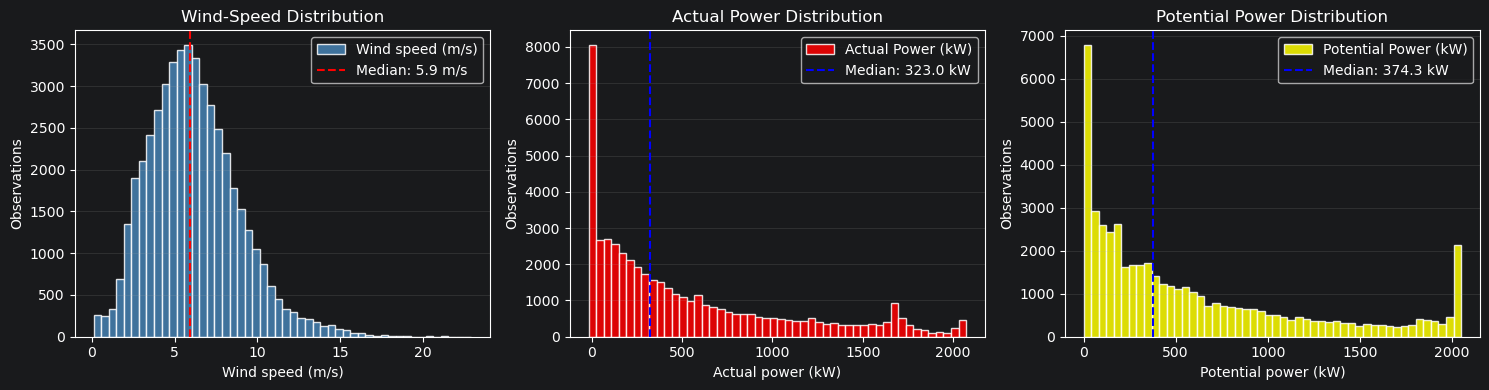

In [15]:
fig, axes = plt.subplots(1,3, figsize=(15,4))
wind_speed = core_performance_data["Wind speed (m/s)"]
actual_power = core_performance_data["Power (kW)"]
potential_power = core_performance_data["Potential power default PC (kW)"]

axes[0].hist(wind_speed.dropna(), bins=50, label="Wind speed (m/s)", color="steelblue", edgecolor="white", alpha=0.85)

axes[0].axvline(
    wind_speed.median(),
    color="red",
    linestyle="--",
    label=f"Median: {wind_speed.median():.1f} m/s",
)

axes[1].hist(actual_power.dropna(), bins=50, label="Actual Power (kW)", color="red", edgecolor="white", alpha=0.85)

axes[1].axvline(
    actual_power.median(),
    color="blue",
    linestyle="--",
    label=f"Median: {actual_power.median():.1f} kW",
)

axes[2].hist(potential_power.dropna(), bins=50, label="Potential Power (kW)", color="yellow", edgecolor="white", alpha=0.85)

axes[2].axvline(
    potential_power.median(),
    color="blue",
    linestyle="--",
    label=f"Median: {potential_power.median():.1f} kW",
)

axes[0].set_title("Wind-Speed Distribution")
axes[0].set_xlabel("Wind speed (m/s)")
axes[0].set_ylabel("Observations")
axes[0].legend()

axes[1].set_title("Actual Power Distribution")
axes[1].set_xlabel("Actual power (kW)")
axes[1].set_ylabel("Observations")
axes[1].legend()

axes[2].set_title("Potential Power Distribution")
axes[2].set_xlabel("Potential power (kW)")
axes[2].set_ylabel("Observations")
axes[2].legend()

for axis in axes:
    axis.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

### Distribution Findings

Wind speed is concentrated primarily between approximately 4 and 9 m/s, with a median of 5.91 m/s and relatively few observations at very high wind speeds.

Actual and potential power are both strongly right-skewed and contain large concentrations near zero. Near-zero actual power may result from low wind, downtime, curtailment, or other non-producing operating states, so it cannot be classified from the histogram alone.

Potential power contains a distinct concentration at 2,050 kW, consistent with an expected-power estimate capped at the turbine’s apparent rated capacity. Actual power shows a different high-output pattern, including a concentration below rated capacity.

Actual power has a lower mean and median than potential power. This indicates an aggregate production gap but does not by itself demonstrate abnormal underperformance. The two power signals must be compared at matching timestamps and wind conditions.

### 6.3 Compare Wind Speed with Actual and Potential Power

A turbine power curve describes how electrical output changes with wind speed. Comparing actual and potential power against the same wind-speed observations helps reveal normal operating behaviour, rated-power limits, and observations where actual production falls below the expected pattern.

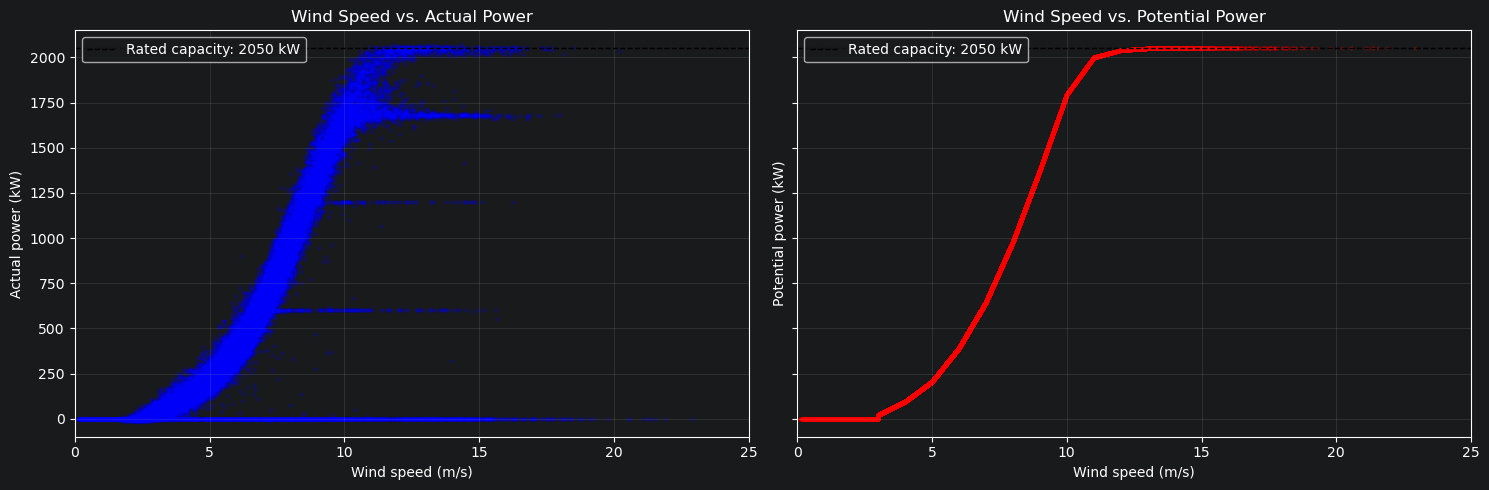

In [16]:
performance_plot_data = core_performance_data.dropna()
fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5),
    sharex=True,
    sharey=True,
)
axes[0].scatter(x=performance_plot_data["Wind speed (m/s)"], y=performance_plot_data["Power (kW)"], s=5, alpha=0.15, color="blue")
axes[0].set_title("Wind Speed vs. Actual Power")
axes[0].set_xlabel("Wind speed (m/s)")
axes[0].set_ylabel("Actual power (kW)")

axes[1].scatter(x=performance_plot_data["Wind speed (m/s)"], y=performance_plot_data["Potential power default PC (kW)"], s=5, alpha=0.15, color="red")
axes[1].set_title("Wind Speed vs. Potential Power")
axes[1].set_xlabel("Wind speed (m/s)")
axes[1].set_ylabel("Potential power (kW)")

for axis in axes:
    axis.axhline(
        2050,
        color="black",
        linestyle="--",
        linewidth=1,
        label="Rated capacity: 2050 kW",
    )
    axis.set_xlim(0, 25)
    axis.set_ylim(-100, 2150)
    axis.grid(alpha=0.2)
    axis.legend(loc="upper left")

plt.tight_layout()
plt.show()

### Power-Curve Findings

Default potential power follows a smooth reference power curve: expected production remains near zero at low wind speeds, increases rapidly between approximately 3 and 11 m/s, and reaches the 2,050 kW capacity ceiling at higher wind speeds. This indicates that default potential power is a calculated reference based strongly on wind speed rather than an independent physical measurement.

Actual power broadly follows the same rising relationship but contains substantially more variation. A dense group of observations follows the expected curve, while a horizontal near-zero band extends across moderate and high wind speeds. Additional horizontal bands appear near approximately 600, 1,200, and 1,650–1,700 kW.

The repeated horizontal bands suggest distinct operating limits or modes that may be associated with setpoints, curtailment, derating, or availability conditions. Observations below the expected curve cannot yet be classified as faults because their operational and status context has not been examined.

The difference between the smooth potential-power curve and the multi-pattern actual-power curve provides the central investigation problem for the project.

### 6.4 Quantify the Actual–Potential Power Gap

The difference between default potential power and actual power provides an initial measure of deviation from the reference power curve.

This difference is treated as a power gap rather than confirmed production loss because operational limitations, availability, curtailment, and model uncertainty have not yet been considered.

In [17]:
performance_analysis_data = turbine_1[[
    "Date and time",
    "Wind speed (m/s)",
    "Power (kW)",
    "Potential power default PC (kW)"
]].dropna().copy()

performance_analysis_data["Power gap (kW)"] = performance_analysis_data["Potential power default PC (kW)"] - performance_analysis_data["Power (kW)"]

performance_analysis_data.describe()

,Date and time,Wind speed (m/s),Power (kW),Potential power default PC (kW),Power gap (kW)
count,48485,48485.000000,48485.000000,48485.000000,48485.000000
mean,2016-07-13 11:45:33.826956544,6.168942,520.897390,596.350200,75.452809
min,2016-01-23 12:10:00,0.114947,-16.652830,0.000000,-467.463174
25%,2016-04-18 07:30:00,4.234505,87.578552,120.030075,-14.906828
50%,2016-07-13 09:00:00,5.910000,323.035889,374.259972,7.164406
75%,2016-10-06 11:40:00,7.775368,800.038879,903.972983,51.179995
max,2016-12-31 23:50:00,22.910000,2072.454590,2050.000000,2055.230000
std,NaN,2.729510,544.783016,604.735856,306.529207


In [18]:
positive_gap_count = (
    performance_analysis_data["Power gap (kW)"] > 0
).sum()

negative_gap_count = (
    performance_analysis_data["Power gap (kW)"] < 0
).sum()

zero_gap_count = (
    performance_analysis_data["Power gap (kW)"] == 0
).sum()

print("Number of observations with gap 0: ", zero_gap_count)
print("Number of observations with positive gap: ", positive_gap_count)
print("Number of observations with negative gap: ", negative_gap_count)

Number of observations with gap 0:  0
Number of observations with positive gap:  30838
Number of observations with negative gap:  17647


### Power-Gap Findings

Among the 48,485 observations with complete wind-speed, actual-power, and potential-power data, 30,838 observations (approximately 63.6%) have a positive power gap and 17,647 observations (approximately 36.4%) have a negative gap. No observations have an exact zero gap.

The median gap is approximately 7.16 kW, while the mean is substantially higher at approximately 75.45 kW. This difference indicates a right-skewed distribution in which a smaller number of large positive gaps raise the average.

Positive gaps indicate that actual power is below the default potential-power reference, but they do not by themselves establish production loss or turbine malfunction. Negative gaps indicate that actual power exceeds the reference estimate and may reflect normal variation or limitations in the default power-curve calculation.

Complete core-performance data begins on 2016-01-23 at 12:10, later than the raw timestamp coverage. The timing and operational context of missing and large-gap observations must therefore be examined before defining underperformance cases.

## 7. Examine Operational Context

Power below the default potential-power curve is not necessarily abnormal. A turbine may be unavailable, intentionally limited by a power setpoint, curtailed, or affected by downtime.

We therefore examine operational and production-loss variables that may explain the patterns observed in the actual-power curve.

### 7.1 Validate Operational Context Variables

Before relating operational context to power gaps, we evaluate the availability, ranges, and variation of the relevant variables.

In [19]:
operational_context_columns = [
    "Data Availability",
    "Available Capacity for Production (kW)",
    "Turbine Power setpoint (kW)",
    "Time-based System Avail.",
    "Lost Production to Downtime (kWh)",
    "Lost Production to Performance (kWh)",
    "Lost Production to Curtailment (Total) (kWh)",
]

operational_context_data = turbine_1[operational_context_columns]
operational_context_summary = operational_context_data.describe().T
operational_context_summary["Unique count"] = (
    operational_context_data.nunique()
)

operational_context_summary["Missing count"] = (
    operational_context_data.isna().sum()
)

operational_context_summary["Missing percentage"] = (
    operational_context_summary["Missing count"]
    / len(turbine_1)
    * 100
)

operational_context_summary

,count,mean,std,min,25%,50%,75%,max,Unique count,Missing count,Missing percentage
Data Availability,52416.0,0.925004,0.263388,0.000000,1.000000,1.0,1.000000,1.000000,2,0,0.000000
Available Capacity for Production (kW),50325.0,1873.327341,573.313123,0.000000,2050.000000,2050.0,2050.000000,2050.000000,138,2091,3.989240
Turbine Power setpoint (kW),0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,52416,100.000000
Time-based System Avail.,50325.0,0.913818,0.279665,0.000000,1.000000,1.0,1.000000,1.000000,138,2091,3.989240
Lost Production to Downtime (kWh),49005.0,8.769580,44.191261,0.000000,0.000000,0.0,0.000000,343.053345,2330,3411,6.507555
Lost Production to Performance (kWh),48485.0,0.163392,15.505220,-81.089102,-3.951615,0.0,4.040189,281.162146,42064,3931,7.499618
Lost Production to Curtailment (Total) (kWh),49097.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,1,3319,6.332036


### Operational Context Availability Findings

`Data Availability` is complete and binary, with a mean of approximately 0.925. This closely matches the 92.5% availability of the three core performance variables, suggesting that it may directly identify rows where those measurements are unavailable.

`Available Capacity for Production (kW)` is available for approximately 96% of observations and is normally 2,050 kW, but it also reaches zero and contains 138 distinct values. It may therefore help explain reduced-output operating modes.

`Turbine Power setpoint (kW)` is entirely empty for Turbine 1 in 2016 and cannot be used in this sample analysis. Its availability should be checked again across other turbines and years.

`Time-based System Avail.` has the same coverage and number of unique values as available capacity, suggesting that it may be a normalized version of available capacity rather than independent evidence.

Downtime loss is usually zero but contains substantial positive values during some intervals. Performance loss contains both positive and negative values and cannot be treated as a simple non-negative loss measurement. The total curtailment-loss field is zero wherever present, so more specific curtailment fields may need to be inspected later.

### 7.2 Relate Data Availability to Missing Core Measurements

We test whether the binary data-availability indicator corresponds directly to missing wind-speed, actual-power, and potential-power observations.

In [20]:
core_measurements_missing = turbine_1[
    core_performance_columns
].isna().all(axis=1)

availability_missing_crosstab = pd.crosstab(
    index=turbine_1["Data Availability"],
    columns=core_measurements_missing,
    rownames=["Data Availability"],
    colnames=["All core measurements missing"],
    margins=True,
)

availability_missing_crosstab

All core measurements missing,False,True,All
Data Availability,,,
0,0,3931,3931
1,48485,0,48485
All,48485,3931,52416


### Data-Availability Finding

`Data Availability` perfectly matches the availability of wind speed, actual power, and default potential power for Turbine 1 in 2016.

All 3,931 rows where `Data Availability` equals 0 have all three core measurements missing. All 48,485 rows where it equals 1 contain the three measurements.

Rows with `Data Availability = 0` will therefore be excluded from calculations requiring wind and power, but they will remain in the cleaned source dataset so their timestamps and status-event context are preserved.

### 7.3 Test the Available-Capacity Relationship

Available capacity and time-based system availability have identical coverage and numbers of unique values. We test whether system availability is simply available capacity normalized by the turbine’s 2,050 kW rated capacity.

Identifying derived or redundant variables prevents the investigation system from treating the same evidence as two independent signals.

In [21]:
available_capacity_relation = turbine_1[
    [
        "Available Capacity for Production (kW)",
        "Time-based System Avail.",
    ]
].dropna().copy()

available_capacity_relation["Calculated system availability"] = (
    available_capacity_relation["Available Capacity for Production (kW)"]
    / 2050
)

available_capacity_relation["Difference"] = (
    available_capacity_relation["Time-based System Avail."]
    - available_capacity_relation["Calculated system availability"]
)

print(available_capacity_relation.describe())

       Available Capacity for Production (kW)  Time-based System Avail.  \
count                            50325.000000              50325.000000   
mean                              1873.327341                  0.913818   
std                                573.313123                  0.279665   
min                                  0.000000                  0.000000   
25%                               2050.000000                  1.000000   
50%                               2050.000000                  1.000000   
75%                               2050.000000                  1.000000   
max                               2050.000000                  1.000000   

       Calculated system availability    Difference  
count                    50325.000000  5.032500e+04  
mean                         0.913818  5.391172e-20  
std                          0.279665  3.653070e-18  
min                          0.000000 -1.110223e-16  
25%                          1.000000  0.000000e+00  


In [22]:
print("Largest absolute difference", available_capacity_relation["Difference"].abs().max())

Largest absolute difference 1.1102230246251565e-16


### Available-Capacity Relationship Finding

`Time-based System Avail.` is mathematically equivalent to `Available Capacity for Production (kW)` divided by the turbine’s 2,050 kW rated capacity. The largest observed difference is approximately \(1.11 \times 10^{-16}\), which is negligible floating-point rounding error.

The variables therefore contain redundant information. Available capacity will be preferred for investigation because its kilowatt scale is directly comparable with actual and potential power. The original system-availability field will remain in the source data but does not need to be used as separate analytical evidence.

### 7.4 Summarize Available-Capacity States

Reduced available capacity may explain horizontal bands and below-reference observations in the actual-power curve. We classify timestamps according to whether available capacity is missing, zero, reduced, or at the full 2,050 kW rating.

In [23]:
available_capacity = operational_context_data[
    "Available Capacity for Production (kW)"
]

missing_capacity = available_capacity.isna().sum()
zero_capacity = (available_capacity == 0).sum()
reduced_capacity = (
    (available_capacity > 0)
    & (available_capacity < 2050)
).sum()
full_capacity = (available_capacity == 2050).sum()

total_rows = len(available_capacity)
classified_capacity_rows = (
    missing_capacity
    + zero_capacity
    + reduced_capacity
    + full_capacity
)

print(
    "Missing capacity observations:",
    missing_capacity,
    f"({missing_capacity / total_rows * 100:.2f}%)",
)
print(
    "Zero capacity observations:",
    zero_capacity,
    f"({zero_capacity / total_rows * 100:.2f}%)",
)
print(
    "Reduced capacity observations:",
    reduced_capacity,
    f"({reduced_capacity / total_rows * 100:.2f}%)",
)
print(
    "Full capacity observations:",
    full_capacity,
    f"({full_capacity / total_rows * 100:.2f}%)",
)
print("Total classified rows:", classified_capacity_rows)
print("Expected rows:", total_rows)


Missing capacity observations: 2091 (3.99%)
Zero capacity observations: 4265 (8.14%)
Reduced capacity observations: 174 (0.33%)
Full capacity observations: 45886 (87.54%)
Total classified rows: 52416
Expected rows: 52416


### Available-Capacity State Findings

Available capacity is at the full 2,050 kW rating for 45,886 timestamps, representing approximately 87.54% of all Turbine 1 observations. It is zero for 4,265 timestamps (8.14%) and reduced but greater than zero for only 174 timestamps (0.33%). Capacity is missing for 2,091 timestamps (3.99%).

Zero available capacity may explain some near-zero actual-power observations, while the small number of reduced-capacity timestamps may explain some intentionally limited output. However, the capacity states must be compared directly with actual and potential power before they are treated as explanations.

Missing capacity remains distinct from zero capacity and will not be interpreted as turbine unavailability.

### 7.5 Compare Capacity States with Power

We compare actual power, potential power, and the power gap across full, reduced, and zero available-capacity states. This tests whether capacity restrictions explain the below-reference patterns observed in the power curve.

In [24]:
capacity_performance_data = performance_analysis_data.join(
    turbine_1[["Available Capacity for Production (kW)"]]
)

capacity_performance_data = capacity_performance_data.dropna(
    subset=["Available Capacity for Production (kW)"]
).copy()

In [25]:
capacity_performance_data["Capacity state"] = "Full"

capacity = capacity_performance_data[
    "Available Capacity for Production (kW)"
]

capacity_performance_data.loc[
    capacity == 0,
    "Capacity state",
] = "Zero"

capacity_performance_data.loc[
    (capacity > 0) & (capacity < 2050),
    "Capacity state",
] = "Reduced"

In [26]:
capacity_state_summary = (
    capacity_performance_data
    .groupby("Capacity state")
    .agg(
        observations=("Power (kW)", "size"),
        mean_actual_power_kw=("Power (kW)", "mean"),
        mean_potential_power_kw=(
            "Potential power default PC (kW)",
            "mean",
        ),
        mean_power_gap_kw=("Power gap (kW)", "mean"),
        median_power_gap_kw=("Power gap (kW)", "median"),
    )
    .round(2)
)

capacity_state_summary

,observations,mean_actual_power_kw,mean_potential_power_kw,mean_power_gap_kw,median_power_gap_kw
Capacity state,,,,,
Full,45886,550.00,573.07,23.07,4.76
Reduced,174,117.40,401.30,283.90,69.62
Zero,2425,-0.78,1050.94,1051.72,965.75


### Capacity-State Performance Findings

All 48,485 observations with complete wind-speed, actual-power, and potential-power data also contain available-capacity information.

During full-capacity operation, actual power is generally close to the default potential-power reference: the median gap is approximately 4.76 kW, although some larger deviations raise the mean gap to 23.07 kW.

Reduced-capacity operation occurs in only 174 complete observations and is associated with lower actual power and a larger mean gap of approximately 283.90 kW. These observations may explain some limited-output periods but are too few to explain every horizontal band in the power curve.

When available capacity is zero, mean actual power is approximately -0.78 kW while mean potential power exceeds 1,050 kW. The resulting mean gap of approximately 1,051.72 kW reflects unavailable or restricted operation rather than unexplained turbine underperformance.

Available capacity therefore explains a substantial part of the largest power gaps. Investigation-case detection must separate zero- and reduced-capacity periods from unexplained gaps during full-capacity operation.

### 7.6 Compare Recorded Losses Across Capacity States

We examine whether Greenbyte’s downtime and performance-loss estimates agree with the available-capacity states. This helps determine which derived loss variables can support investigation explanations.

In [27]:
loss_analysis_data = capacity_performance_data.join(
    turbine_1[["Lost Production to Downtime (kWh)",
               "Lost Production to Performance (kWh)"]]
)

In [28]:
loss_by_capacity_summary = (
    loss_analysis_data
    .groupby("Capacity state")
    .agg(
        observations=("Power (kW)", "size"),

        available_downtime_values=(
            "Lost Production to Downtime (kWh)",
            "count",
        ),

        positive_downtime_observations=(
            "Lost Production to Downtime (kWh)",
            lambda values: (values > 0).sum(),
        ),

        total_downtime_loss_kwh=(
            "Lost Production to Downtime (kWh)",
            "sum",
        ),

        mean_downtime_loss_kwh=(
            "Lost Production to Downtime (kWh)",
            "mean",
        ),

        mean_performance_loss_kwh=(
            "Lost Production to Performance (kWh)",
            "mean",
        ),

        mean_power_gap_kw=(
            "Power gap (kW)",
            "mean",
        ),
    )
    .round(2)
)

loss_by_capacity_summary

,observations,available_downtime_values,positive_downtime_observations,total_downtime_loss_kwh,mean_downtime_loss_kwh,mean_performance_loss_kwh,mean_power_gap_kw
Capacity state,,,,,,,
Full,45886,45886,0,0.00,0.00,0.17,23.07
Reduced,174,174,120,8058.82,46.32,0.00,283.90
Zero,2425,2425,2204,372951.67,153.79,0.00,1051.72


### Recorded-Loss Findings

Recorded downtime loss strongly agrees with available-capacity state. No full-capacity observation has positive downtime loss, while approximately 69% of reduced-capacity observations and 91% of zero-capacity observations have positive downtime loss.

Zero-capacity periods have a mean power gap of approximately 1,051.72 kW and a mean recorded downtime loss of 153.79 kWh. Reduced-capacity periods have a mean power gap of approximately 283.90 kW and a mean downtime loss of 46.32 kWh.

Full-capacity gaps are not classified as downtime loss. Their mean performance-loss estimate is small, so additional operational, curtailment, and status evidence may be needed to explain the larger full-capacity deviations.

Power gap and recorded loss use different units and must not be compared directly. The ten-minute power gap must first be converted from kilowatts to kilowatt-hours.

In [29]:
loss_analysis_data["Power gap energy (kWh)"] = loss_analysis_data["Power gap (kW)"] / 6

loss_analysis_data["Residual after downtime (kWh)"] = loss_analysis_data["Power gap energy (kWh)"] - loss_analysis_data["Lost Production to Downtime (kWh)"]

In [30]:
gap_energy_by_capacity_summary = (
    loss_analysis_data
    .groupby("Capacity state")
    .agg(
        mean_power_gap_energy=("Power gap energy (kWh)", "mean"),
        mean_downtime_loss_kwh=("Lost Production to Downtime (kWh)", "mean"),
        mean_residual_after_downtime_kwh=("Residual after downtime (kWh)", "mean"),
        median_residual_after_downtime_kwh=("Residual after downtime (kWh)", "median"),
    )
    .round(2)
)

gap_energy_by_capacity_summary

,mean_power_gap_energy,mean_downtime_loss_kwh,mean_residual_after_downtime_kwh,median_residual_after_downtime_kwh
Capacity state,,,,
Full,3.84,0.00,3.84,0.79
Reduced,47.32,46.32,1.00,0.27
Zero,175.29,153.79,21.49,0.10


### Gap-Energy Reconciliation Findings

Converting the ten-minute power gap to energy allows direct comparison with Greenbyte’s recorded downtime loss.

For reduced-capacity observations, mean gap energy is approximately 47.32 kWh and mean downtime loss is 46.32 kWh, leaving a mean residual of only 1.00 kWh. Recorded downtime therefore explains nearly all reduced-capacity gap energy.

For zero-capacity observations, mean gap energy is 175.29 kWh and mean downtime loss is 153.79 kWh. Although the mean residual is 21.49 kWh, the median residual is only 0.10 kWh. This indicates that downtime explains the typical zero-capacity observation, while a smaller number of large residuals increase the average.

Full-capacity observations contain no recorded downtime loss. Their median residual is relatively small at 0.79 kWh, but the higher mean of 3.84 kWh suggests a smaller number of larger deviations requiring additional curtailment or status evidence.

### 7.7 Inspect Specific Curtailment-Loss Variables

The total-curtailment field contains only zero values, but the export includes separate curtailment categories. We inspect those fields to determine whether any category records positive loss during Turbine 1’s 2016 operation.

In [31]:
curtailment_columns = [
    column
    for column in turbine_1.columns
    if column.startswith("Lost Production to Curtailment")
]

print("Curtailment columns found:", len(curtailment_columns))

for column in curtailment_columns:
    print(f"  - {column}")

Curtailment columns found: 12
  - Lost Production to Curtailment (Total) (kWh)
  - Lost Production to Curtailment (Grid) (kWh)
  - Lost Production to Curtailment (Noise) (kWh)
  - Lost Production to Curtailment (Shadow) (kWh)
  - Lost Production to Curtailment (Bats) (kWh)
  - Lost Production to Curtailment (Birds) (kWh)
  - Lost Production to Curtailment (Ice) (kWh)
  - Lost Production to Curtailment (Sector Management) (kWh)
  - Lost Production to Curtailment (Technical) (kWh)
  - Lost Production to Curtailment (Marketing) (kWh)
  - Lost Production to Curtailment (Boat Action) (kWh)
  - Lost Production to Curtailment (Grid Constraint) (kWh)


In [32]:
curtailment_data = turbine_1[curtailment_columns]

curtailment_summary = pd.DataFrame(
    {
        "Available count": curtailment_data.count(),
        "Positive count": (curtailment_data > 0).sum(),
        "Total loss (kWh)": curtailment_data.sum(),
        "Maximum loss (kWh)": curtailment_data.max(),
    }
)

curtailment_summary = curtailment_summary.sort_values(
    by="Total loss (kWh)",
    ascending=False,
)

curtailment_summary

,Available count,Positive count,Total loss (kWh),Maximum loss (kWh)
Lost Production to Curtailment (Total) (kWh),49097,0,0.0,0.0
Lost Production to Curtailment (Grid) (kWh),49097,0,0.0,0.0
Lost Production to Curtailment (Noise) (kWh),49097,0,0.0,0.0
Lost Production to Curtailment (Shadow) (kWh),49097,0,0.0,0.0
Lost Production to Curtailment (Bats) (kWh),49097,0,0.0,0.0
Lost Production to Curtailment (Birds) (kWh),49097,0,0.0,0.0
Lost Production to Curtailment (Ice) (kWh),49097,0,0.0,0.0
Lost Production to Curtailment (Sector Management) (kWh),49097,0,0.0,0.0
Lost Production to Curtailment (Technical) (kWh),49097,0,0.0,0.0
Lost Production to Curtailment (Marketing) (kWh),49097,0,0.0,0.0


### Curtailment-Loss Findings

All 12 exported curtailment-loss categories contain zero positive values for Turbine 1 in 2016. This includes total, grid, noise, shadow, wildlife, ice, sector-management, technical, marketing, boat-action, and grid-constraint curtailment.

These fields therefore cannot explain the observed full-capacity power gaps or horizontal output bands. However, zero recorded values do not prove that curtailment never occurred; relevant operating limitations may be represented by status events or may not have been populated in these loss fields.

## 8. Explore Monthly Performance Patterns

Monthly aggregation reveals seasonal changes in wind conditions, production, expected production, downtime loss, and data availability. These patterns help identify periods worth investigating while preventing incomplete months from being mistaken for poor turbine performance.

In [33]:
monthly_source = turbine_1[
    [
        "Date and time",
        "Wind speed (m/s)",
        "Power (kW)",
        "Potential power default PC (kW)",
        "Data Availability",
        "Lost Production to Downtime (kWh)",
    ]
].copy()

monthly_source["Actual interval energy (kWh)"] = (
    monthly_source["Power (kW)"] / 6
)

monthly_source["Potential interval energy (kWh)"] = (
    monthly_source["Potential power default PC (kW)"] / 6
)

In [34]:
monthly_summary = (
    monthly_source
    .resample(
        "MS",
        on="Date and time",
    )
    .agg(
        observed_intervals=("Data Availability", "size"),

        mean_wind_speed_ms=(
            "Wind speed (m/s)",
            "mean",
        ),

        actual_energy_kwh=(
            "Actual interval energy (kWh)",
            "sum",
        ),

        potential_energy_kwh=(
            "Potential interval energy (kWh)",
            "sum",
        ),

        mean_data_availability=(
            "Data Availability",
            "mean",
        ),

        downtime_loss_kwh=(
            "Lost Production to Downtime (kWh)",
            "sum",
        ),
    )
)

In [35]:
monthly_summary["Actual energy (MWh)"] = (
    monthly_summary["actual_energy_kwh"] / 1000
)

monthly_summary["Potential energy (MWh)"] = (
    monthly_summary["potential_energy_kwh"] / 1000
)

monthly_summary["Downtime loss (MWh)"] = (
    monthly_summary["downtime_loss_kwh"] / 1000
)

In [36]:
monthly_summary["Data availability (%)"] = (
    monthly_summary["mean_data_availability"] * 100
)

In [37]:
monthly_summary["expected_intervals"] = (
    monthly_summary.index.days_in_month * 24 * 6
)

monthly_summary["Timestamp coverage (%)"] = (
    monthly_summary["observed_intervals"]
    / monthly_summary["expected_intervals"]
    * 100
)

In [38]:
monthly_summary[
    [
        "observed_intervals",
        "expected_intervals",
        "Timestamp coverage (%)",
        "Data availability (%)",
        "mean_wind_speed_ms",
        "Actual energy (MWh)",
        "Potential energy (MWh)",
        "Downtime loss (MWh)",
    ]
]

,observed_intervals,expected_intervals,Timestamp coverage (%),Data availability (%),mean_wind_speed_ms,Actual energy (MWh),Potential energy (MWh),Downtime loss (MWh)
Date and time,,,,,,,,
2016-01-01,4176,4464,93.548387,25.000000,10.935211,14.837175,272.656469,242.289489
2016-02-01,4176,4176,100.000000,99.904215,7.736016,590.154680,653.282443,38.681182
2016-03-01,4464,4464,100.000000,98.835125,6.132403,420.924050,439.860017,16.668805
2016-04-01,4320,4320,100.000000,97.245370,5.887486,263.870632,372.509167,106.338246
2016-05-01,4464,4464,100.000000,96.953405,5.816951,348.623285,369.243897,0.592031
2016-06-01,4320,4320,100.000000,99.861111,4.799991,220.355006,237.486135,2.270139
2016-07-01,4464,4464,100.000000,99.327957,5.979708,368.877407,402.677128,0.141515
2016-08-01,4464,4464,100.000000,98.969534,5.977355,378.612027,415.624336,0.433326
2016-09-01,4320,4320,100.000000,98.379630,6.080927,375.618472,411.130587,1.601997


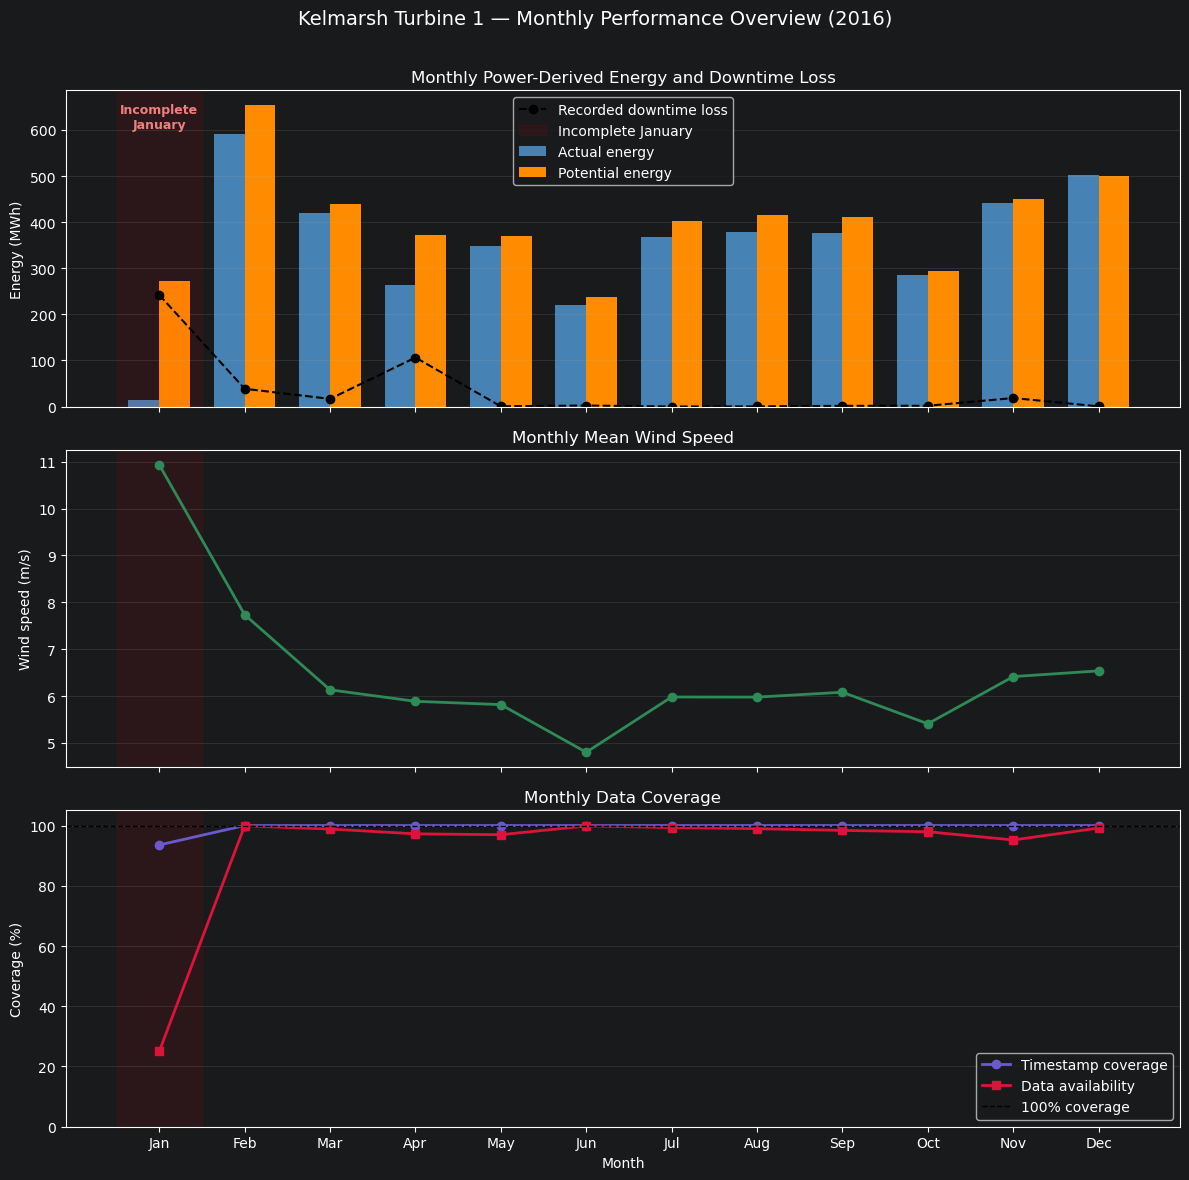

In [39]:
month_labels = monthly_summary.index.strftime("%b")
month_positions = np.arange(len(month_labels))
bar_width = 0.36

fig, axes = plt.subplots(
    3,
    1,
    figsize=(12, 12),
    sharex=True,
)

# Panel 1: Monthly energy
axes[0].bar(
    month_positions - bar_width / 2,
    monthly_summary["Actual energy (MWh)"],
    width=bar_width,
    label="Actual energy",
    color="steelblue",
)

axes[0].bar(
    month_positions + bar_width / 2,
    monthly_summary["Potential energy (MWh)"],
    width=bar_width,
    label="Potential energy",
    color="darkorange",
)

axes[0].plot(
    month_positions,
    monthly_summary["Downtime loss (MWh)"],
    color="black",
    linestyle="--",
    marker="o",
    label="Recorded downtime loss",
)

axes[0].set_title("Monthly Power-Derived Energy and Downtime Loss")
axes[0].set_ylabel("Energy (MWh)")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.2)

# Panel 2: Monthly wind speed
axes[1].plot(
    month_positions,
    monthly_summary["mean_wind_speed_ms"],
    color="seagreen",
    marker="o",
    linewidth=2,
)

axes[1].set_title("Monthly Mean Wind Speed")
axes[1].set_ylabel("Wind speed (m/s)")
axes[1].grid(axis="y", alpha=0.2)

# Panel 3: Monthly data coverage
axes[2].plot(
    month_positions,
    monthly_summary["Timestamp coverage (%)"],
    color="slateblue",
    marker="o",
    linewidth=2,
    label="Timestamp coverage",
)

axes[2].plot(
    month_positions,
    monthly_summary["Data availability (%)"],
    color="crimson",
    marker="s",
    linewidth=2,
    label="Data availability",
)

axes[2].axhline(
    100,
    color="black",
    linestyle="--",
    linewidth=1,
    label="100% coverage",
)

axes[2].set_title("Monthly Data Coverage")
axes[2].set_ylabel("Coverage (%)")
axes[2].set_ylim(0, 105)
axes[2].set_xticks(month_positions)
axes[2].set_xticklabels(month_labels)
axes[2].set_xlabel("Month")
axes[2].legend()
axes[2].grid(axis="y", alpha=0.2)

# Highlight incomplete January
for index, axis in enumerate(axes):
    january_label = (
        "Incomplete January"
        if index == 0
        else "_nolegend_"
    )

    axis.axvspan(
        -0.5,
        0.5,
        color="red",
        alpha=0.08,
        label=january_label,
    )

axes[0].text(
    0,
    0.96,
    "Incomplete\nJanuary",
    transform=axes[0].get_xaxis_transform(),
    ha="center",
    va="top",
    color="lightcoral",
    fontsize=9,
    fontweight="bold",
)

axes[0].legend()

fig.suptitle(
    "Kelmarsh Turbine 1 — Monthly Performance Overview (2016)",
    fontsize=14,
)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

### Monthly Performance Findings

January is incomplete and should not be compared directly with the other months. Timestamp coverage is approximately 93.55% because January 1–2 are absent, while core measurement availability is only 25%. January’s wind and energy statistics therefore represent only the available portion of the month.

February records the highest actual energy production at approximately 590 MWh and relatively high mean wind speed. April contains one of the largest actual–potential energy differences, which is almost entirely matched by recorded downtime loss.

Most months from February onward have data availability above 95%. Nevertheless, several high-availability months retain differences between actual and potential energy, indicating that missing data alone does not explain all monthly variation.

December actual energy slightly exceeds default potential energy, reinforcing that default potential power is a reference estimate rather than exact ground truth.

## 9. Inspect Status-Event Data

SCADA measurements show what the turbine was doing, while status-event records may help explain why its operation changed. We inspect the status-file structure before loading and aligning events with performance data.

### 9.1 Inspect the Raw Status File Structure

We begin with the Turbine 1 status file and inspect a small number of raw text lines. This reveals the metadata, header location, event fields, timestamp format, and status descriptions without assuming that the status export has the same structure as the SCADA export.

In [40]:
sample_status_path = status_files[0]
with open(
    sample_status_path,
    mode="r",
    encoding="utf-8",
    errors="replace",
) as file:
    for line_number, line in enumerate(file, start=1):
        print(f"{line_number}: {line.rstrip()}")

        if line_number == 20:
            break

1: # This file was exported by Greenbyte at 2022-01-27 10:52:06. Please see https://www.greenbyte.com for more information about Greenbyte.
2: #
3: # Turbine: Kelmarsh 1
4: # Turbine type: Senvion MM92 (Senvion MM92 kW)
5: # Time zone: UTC
6: # Time interval: 2016-01-01 00:00:00 - 2017-01-01 00:00:00 (366 days)
7: #
8: # Kelmarsh 1 Sum production: 4239777 kWh
9: #
10: Timestamp start,Timestamp end,Duration,Status,Code,Message,Comment,Service contract category,IEC category
11: 2016-01-14 19:28:03,2016-01-23 14:36:32,211:08:29,Stop,111,Emergency stop nacelle,,Emergency stop switch (Nacelle) (11),Forced outage
12: 2016-01-14 19:28:03,2016-01-14 19:38:03,00:10:00,Warning,5720,Brake accumulator defect,,Warnings (27),
13: 2016-01-14 19:28:05,2016-01-23 11:27:46,207:59:41,Informational,3835,Cable panel breaker open,,Warnings (27),
14: 2016-01-14 19:28:05,2016-01-23 11:27:46,207:59:41,Informational,3830,Supply circuit breaker earthed,,Warnings (27),Full Performance
15: 2016-01-14 19:28:05,2016

### Raw Status-File Findings

The status export uses the same nine-line metadata structure as the SCADA export, with column names on line 10 and event records beginning on line 11. It must therefore be loaded using `skiprows=9`.

Unlike the ten-minute SCADA table, each status row represents an event interval with start and end timestamps at second-level precision. Events may overlap and can last longer than 24 hours, so they cannot be joined to SCADA using exact timestamp equality.

The first records show an emergency nacelle stop and several simultaneous breaker, transformer-fan, generator-fan, and gear-filter events extending into January 23. These events overlap the beginning of usable core SCADA measurements and may provide evidence for the January downtime period. They do not, however, explain missing measurements before the events began on January 14.

In [41]:
turbine_1_status = pd.read_csv(
    status_files[0],
    skiprows=9,
    parse_dates=["Timestamp start", "Timestamp end"]
)

print("Turbine 1 Status dataframe: ", turbine_1_status.shape)
print("Turbine 1 Status dataframe dtypes: ", turbine_1_status.dtypes)
turbine_1_status.head()

Turbine 1 Status dataframe:  (2122, 9)
Turbine 1 Status dataframe dtypes:  Timestamp start              datetime64[ns]
Timestamp end                        object
Duration                             object
Status                               object
Code                                  int64
Message                              object
Comment                             float64
Service contract category            object
IEC category                         object
dtype: object


,Timestamp start,Timestamp end,Duration,Status,Code,Message,Comment,Service contract category,IEC category
0,2016-01-14 19:28:03,2016-01-23 14:36:32,211:08:29,Stop,111,Emergency stop nacelle,NaN,Emergency stop switch (Nacelle) (11),Forced outage
1,2016-01-14 19:28:03,2016-01-14 19:38:03,00:10:00,Warning,5720,Brake accumulator defect,NaN,Warnings (27),NaN
2,2016-01-14 19:28:05,2016-01-23 11:27:46,207:59:41,Informational,3835,Cable panel breaker open,NaN,Warnings (27),NaN
3,2016-01-14 19:28:05,2016-01-23 11:27:46,207:59:41,Informational,3830,Supply circuit breaker earthed,NaN,Warnings (27),Full Performance
4,2016-01-14 19:28:05,2016-01-23 14:09:18,210:41:13,Warning,3870,Overload transformer fan outlet air,NaN,Warnings (27),Full Performance


### 9.2 Validate Status Timestamps

Event alignment requires valid start and end timestamps. Although event-start values parsed successfully, the event-end column remained text, indicating that it may contain missing, open-ended, or differently formatted values.

In [42]:
original_end_time = turbine_1_status["Timestamp end"]

end_time_temp = pd.to_datetime(
    original_end_time,
    errors="coerce",
)

original_missing_count = original_end_time.isna().sum()

unparseable_end_mask = (
    original_end_time.notna()
    & end_time_temp.isna()
)

unparseable_end_count = unparseable_end_mask.sum()

print(
    "Original missing end timestamps:",
    original_missing_count,
)

print(
    "Unparseable non-missing end timestamps:",
    unparseable_end_count,
)

print("Original values that failed parsing:")

print(
    original_end_time[
        unparseable_end_mask
    ].value_counts(dropna=False)
)

Original missing end timestamps: 0
Unparseable non-missing end timestamps: 649
Original values that failed parsing:
Timestamp end
-    649
Name: count, dtype: int64


In [43]:
events_without_end = turbine_1_status[turbine_1_status["Timestamp end"] == "-"]

In [44]:
events_without_end.head(10)

,Timestamp start,Timestamp end,Duration,Status,Code,Message,Comment,Service contract category,IEC category
26,2016-01-23 13:46:05,-,-,Warning,5100,Service obstacle light,NaN,Warnings (27),NaN
32,2016-01-23 14:11:56,-,-,Informational,1555,Gear heating enabled,NaN,Operating states (28),Technical Standby
33,2016-01-23 14:13:50,-,-,Warning,1920,Particle sensor defect,NaN,Warnings (27),NaN
271,2016-03-16 13:31:13,-,-,Informational,0,System OK,NaN,System OK (32),Full Performance
627,2016-04-25 16:13:52,-,-,Informational,0,System OK,NaN,System OK (32),Full Performance
672,2016-04-27 18:57:36,-,-,Informational,0,System OK,NaN,System OK (32),Full Performance
676,2016-04-27 22:35:17,-,-,Informational,0,System OK,NaN,System OK (32),Full Performance
680,2016-04-27 23:08:15,-,-,Informational,0,System OK,NaN,System OK (32),Full Performance
684,2016-04-30 17:02:03,-,-,Informational,0,System OK,NaN,System OK (32),Full Performance
687,2016-05-03 06:23:36,-,-,Informational,0,System OK,NaN,System OK (32),Full Performance


In [45]:
print(events_without_end["Duration"].value_counts())

Duration
-    649
Name: count, dtype: int64


### Status Timestamp Findings

The status dataset contains 1,473 closed event intervals and 649 start-only records. Start-only records use `-` for both `Timestamp end` and `Duration`.

These records include warnings, operating-state messages, and repeated `System OK` entries. They cannot safely be interpreted as events continuing indefinitely. The project will preserve them as point evidence at their start timestamp, while closed events will be treated as intervals.

SCADA alignment will therefore use interval overlap for closed events and proximity-based matching for start-only records.

In [46]:
status_analysis_data = turbine_1_status.copy()
status_analysis_data["Timestamp end"] = status_analysis_data["Timestamp end"].replace("-", pd.NA)
status_analysis_data["Duration"] = status_analysis_data["Duration"].replace("-", pd.NA)
status_analysis_data["Timestamp end"] = pd.to_datetime(status_analysis_data["Timestamp end"])
status_analysis_data["Duration"] = pd.to_timedelta(status_analysis_data["Duration"])

status_analysis_data["Record type"] = "Interval"

status_analysis_data.loc[
    status_analysis_data["Timestamp end"].isna(),
    "Record type",
] = "Start-only"

print(status_analysis_data.dtypes)

print("\nRecord-type counts:")
print(status_analysis_data["Record type"].value_counts())

print(
    "\nMissing end timestamps:",
    status_analysis_data["Timestamp end"].isna().sum(),
)

print(
    "Missing durations:",
    status_analysis_data["Duration"].isna().sum(),
)

Timestamp start               datetime64[ns]
Timestamp end                 datetime64[ns]
Duration                     timedelta64[ns]
Status                                object
Code                                   int64
Message                               object
Comment                              float64
Service contract category             object
IEC category                          object
Record type                           object
dtype: object

Record-type counts:
Record type
Interval      1473
Start-only     649
Name: count, dtype: int64

Missing end timestamps: 649
Missing durations: 649


### 9.3 Validate Event Durations

For closed intervals, the recorded duration should equal the difference between the end and start timestamps. We validate this relationship before using event intervals for SCADA alignment.

In [47]:
interval_events = status_analysis_data[
    status_analysis_data["Record type"] == "Interval"
].copy()

interval_events["Calculated duration"] = (
    interval_events["Timestamp end"]
    - interval_events["Timestamp start"]
)

interval_events["Duration difference"] = (
    interval_events["Duration"]
    - interval_events["Calculated duration"]
)

nonzero_duration_differences = (
    interval_events["Duration difference"]
    != pd.Timedelta(0)
).sum()

largest_duration_difference = (
    interval_events["Duration difference"]
    .abs()
    .max()
)

print("Interval records:", len(interval_events))

print(
    "Nonzero duration differences:",
    nonzero_duration_differences,
)

print(
    "Largest absolute duration difference:",
    largest_duration_difference,
)

Interval records: 1473
Nonzero duration differences: 0
Largest absolute duration difference: 0 days 00:00:00


### Event-Duration Findings

All 1,473 closed status intervals have recorded durations that exactly match the difference between their end and start timestamps. The status intervals are therefore internally consistent and can be used for time-overlap alignment with SCADA observations.

### 9.4 Summarize Status Events

We summarize event severity, IEC classifications, and repeated messages to understand which status records may provide useful investigation evidence.

In [48]:
print("Status counts:")
print(
    status_analysis_data["Status"]
    .value_counts(dropna=False)
)

print("\nIEC category counts:")
print(
    status_analysis_data["IEC category"]
    .value_counts(dropna=False)
)

Status counts:
Status
Informational    1797
Warning           168
Stop              129
Communication      28
Name: count, dtype: int64

IEC category counts:
IEC category
Full Performance                      991
Out of Environmental Specification    821
NaN                                   152
Technical Standby                      60
Forced outage                          56
Scheduled Maintenance                  31
Out of Electrical Specification         6
Requested Shutdown                      3
Partial Performance                     2
Name: count, dtype: int64


In [49]:
print("Ten most frequent messages:")
print(
    status_analysis_data["Message"]
    .value_counts(dropna=False)
    .head(10)
)

print("\nTen most frequent service-contract categories:")
print(
    status_analysis_data["Service contract category"]
    .value_counts(dropna=False)
    .head(10)
)

Ten most frequent messages:
Message
System OK                         911
Wind < start wind                 753
Brake accumulator defect           68
Absence of wind during run-up      67
Battery test                       40
Manual yaw                         33
Data communication unavailable     28
Manual stop - on site              27
Timeout brake closed               22
Comm. failure FPM                  18
Name: count, dtype: int64

Ten most frequent service-contract categories:
Service contract category
System OK (32)                         912
External stop (low wind speed)  (5)    754
Warnings (27)                          183
Operating states  (28)                 140
Manual stop (service)  (9)              64
NaN                                     28
Overspeed (14)                           8
External stop (grid) (4)                 8
Generator and Converter errors (20)      7
Remote stop (30)                         6
Name: count, dtype: int64


### Status-Event Summary Findings

The status dataset is dominated by informational records. `System OK` and `Wind < start wind` are the two most frequent messages and account for most events. Event frequency alone is therefore not a useful fault indicator.

The IEC categories are dominated by `Full Performance` and `Out of Environmental Specification`, with the latter largely associated with low-wind operation. Smaller but operationally important groups include forced outages, technical standby, scheduled maintenance, requested shutdowns, and partial-performance events.

A total of 152 events lack an IEC classification, so the investigation process must also consider status level, event code, message, duration, and timing rather than relying only on IEC category.

Investigation evidence will prioritize long-duration stops and warnings, forced outages, maintenance or standby events, and records overlapping substantial power gaps.

## 10. Investigate an Evidence-Rich Underperformance Case

### 10.1 Select Candidate Investigation Days

In [50]:
daily_source = loss_analysis_data.copy()
daily_source["Day"] = (
    daily_source["Date and time"].dt.floor("D")
)

daily_source["Actual interval energy (kWh)"] = (
    daily_source["Power (kW)"] / 6
)

daily_source["Potential interval energy (kWh)"] = (
    daily_source["Potential power default PC (kW)"] / 6
)

daily_summary = (
    daily_source
    .groupby("Day")
    .agg(
        complete_observations=(
            "Power (kW)",
            "size",
        ),

        actual_energy_kwh=(
            "Actual interval energy (kWh)",
            "sum",
        ),

        potential_energy_kwh=(
            "Potential interval energy (kWh)",
            "sum",
        ),

        downtime_loss_kwh=(
            "Lost Production to Downtime (kWh)",
            "sum",
        ),

        power_gap_energy_kwh=(
            "Power gap energy (kWh)",
            "sum",
        ),

        mean_available_capacity_kw=(
            "Available Capacity for Production (kW)",
            "mean",
        ),
    )
)
# A complete day contains 24 hours × 6 ten-minute intervals = 144 observations.
daily_summary["Complete-data coverage (%)"] = (
    daily_summary["complete_observations"]
    / 144
    * 100
)

daily_summary["Actual energy (MWh)"] = (
    daily_summary["actual_energy_kwh"] / 1000
)

daily_summary["Potential energy (MWh)"] = (
    daily_summary["potential_energy_kwh"] / 1000
)

daily_summary["Downtime loss (MWh)"] = (
    daily_summary["downtime_loss_kwh"] / 1000
)

daily_summary["Power-gap energy (MWh)"] = (
    daily_summary["power_gap_energy_kwh"] / 1000
)
highest_downtime_days = (
    daily_summary
    .sort_values(
        by="Downtime loss (MWh)",
        ascending=False,
    )
    .head(10)
)

In [51]:
highest_downtime_days[
    [
        "complete_observations",
        "Complete-data coverage (%)",
        "Actual energy (MWh)",
        "Potential energy (MWh)",
        "Downtime loss (MWh)",
        "Power-gap energy (MWh)",
        "mean_available_capacity_kw",
    ]
]

,complete_observations,Complete-data coverage (%),Actual energy (MWh),Potential energy (MWh),Downtime loss (MWh),Power-gap energy (MWh),mean_available_capacity_kw
Day,,,,,,,
2016-02-01,144,100.00,2.431083,48.095945,37.922299,45.664862,358.726273
2016-01-27,144,100.00,-0.028185,44.911690,37.515157,44.939875,0.000000
2016-01-31,144,100.00,-0.010720,33.780007,33.780007,33.790727,0.000000
2016-01-30,144,100.00,-0.010002,39.530473,32.534882,39.540475,0.000000
2016-01-29,144,100.00,-0.009203,49.167217,28.659038,49.176420,0.000000
2016-01-28,144,100.00,-0.017257,37.929888,25.865609,37.947145,0.000000
2016-04-07,144,100.00,9.814192,29.845205,18.678186,20.031013,523.817708
2016-04-06,144,100.00,21.028683,44.640733,18.099946,23.612050,1069.986111
2016-01-26,45,31.25,-0.011518,15.306533,15.324998,15.318052,0.000000


### Daily Production-Loss Findings

The highest recorded downtime losses occurred primarily during late January and early February. Several of these days had almost no actual production and an average available capacity of `0 kW`, indicating that the turbine was unavailable for most or all of the day.

On 1 February, the recorded downtime loss explains most, but not all, of the difference between potential and actual energy. This confirms that the total power gap should not automatically be treated as downtime loss.

Days such as 6 and 7 April are more suitable for detailed investigation because the turbine produced energy while its average available capacity was reduced. These days may contain transitions between normal production, reduced capacity, and unavailability, allowing us to investigate when operating conditions changed and whether status events explain those changes.

### 10.2 Compare Candidate Days

In [52]:
april_case_data = loss_analysis_data[
    (loss_analysis_data["Date and time"] >= "2016-04-06")
    & (loss_analysis_data["Date and time"] < "2016-04-08")
].copy()

april_case_data["Day"] = (
    april_case_data["Date and time"].dt.date
)

april_capacity_state_summary = (
    april_case_data
    .groupby(["Day", "Capacity state"])
    .size()
    .rename("Observations")
    .reset_index()
)

april_capacity_state_summary["Hours"] = (
    april_capacity_state_summary["Observations"] / 6
)

april_capacity_state_summary

,Day,Capacity state,Observations,Hours
0,2016-04-06,Full,74,12.333333
1,2016-04-06,Reduced,2,0.333333
2,2016-04-06,Zero,68,11.333333
3,2016-04-07,Full,36,6.000000
4,2016-04-07,Reduced,1,0.166667
5,2016-04-07,Zero,107,17.833333


### Investigation-Day Selection

Both days contain full-, reduced-, and zero-capacity observations, but 6 April has the more balanced operational profile. The turbine spent approximately 12.33 hours at full capacity, 0.33 hours at reduced capacity, and 11.33 hours at zero capacity.

On 7 April, the turbine was unavailable for approximately 17.83 hours and operated at full capacity for only 6 hours. Therefore, 6 April is selected for detailed investigation because it provides a clearer comparison between normal production and unavailable operation within the same day.

The grouped summary shows the total duration of each capacity state, but it does not preserve their chronological order. A time-based examination is required to identify when the capacity changes occurred.

### 10.3 Identify Capacity Transitions

In [53]:
april_6_mask = (
    april_case_data["Day"]
    == pd.Timestamp("2016-04-06").date()
)

april_6_data = april_case_data.loc[
    april_6_mask
].copy()

april_6_data = april_6_data.sort_values(
    "Date and time"
)

april_6_data["State changed"] = (
    april_6_data["Capacity state"]
    .ne(april_6_data["Capacity state"].shift())
)

In [54]:
april_6_transitions = april_6_data.loc[
    april_6_data["State changed"],
    [
        "Date and time",
        "Available Capacity for Production (kW)",
        "Capacity state",
        "Power (kW)",
        "Potential power default PC (kW)",
        "Power gap (kW)",
    ],
]

april_6_transitions

,Date and time,Available Capacity for Production (kW),Capacity state,Power (kW),Potential power default PC (kW),Power gap (kW)
13536,2016-04-06 00:00:00,0.000000,Zero,-0.540000,1396.000080,1396.540080
13579,2016-04-06 07:10:00,755.083333,Reduced,-5.230000,2050.000000,2055.230000
13580,2016-04-06 07:20:00,0.000000,Zero,-1.160000,1740.399952,1741.559952
13605,2016-04-06 11:30:00,1622.916667,Reduced,48.630001,1872.900023,1824.270022
13606,2016-04-06 11:40:00,2050.000000,Full,1776.619995,2017.999992,241.379997


### Capacity-Transition Findings

Turbine 1 began 6 April at zero available capacity and produced almost no power. At 07:10, it briefly entered a reduced-capacity state, but returned to zero capacity ten minutes later. This was a brief capacity change, but the ten-minute SCADA data alone cannot explain why it occurred.

A more substantial recovery began at 11:30. Available capacity increased to approximately 1,623 kW, followed by full 2,050 kW capacity at 11:40. Actual power simultaneously increased from approximately 49 kW to 1,777 kW.

Potential power was already high during this transition, indicating that sufficient wind energy was available. The increase in production is therefore more consistent with restored turbine availability than with a sudden increase in wind.

### 10.4 Align Status Events with the Investigation

In [55]:
case_start = pd.Timestamp("2016-04-06 00:00:00")
case_end = pd.Timestamp("2016-04-07 00:00:00")

interval_overlap_mask = (
    (status_analysis_data["Record type"] == "Interval")
    & (status_analysis_data["Timestamp start"] < case_end)
    & (status_analysis_data["Timestamp end"] >= case_start)
)

overlapping_intervals = status_analysis_data[
    interval_overlap_mask
].copy()

overlapping_intervals[
    [
        "Timestamp start",
        "Timestamp end",
        "Duration",
        "Status",
        "Message",
        "IEC category",
    ]
]

,Timestamp start,Timestamp end,Duration,Status,Message,IEC category
401,2016-04-05 17:22:23,2016-04-06 07:15:07,0 days 13:52:44,Stop,Feedback brake 1,Forced outage
402,2016-04-06 07:09:08,2016-04-06 07:09:20,0 days 00:00:12,Warning,Brake accumulator defect,NaN
403,2016-04-06 07:09:20,2016-04-06 07:09:42,0 days 00:00:22,Informational,System OK,Full Performance
404,2016-04-06 07:12:33,2016-04-06 07:15:07,0 days 00:02:34,Warning,Brake accumulator defect,NaN
405,2016-04-06 07:15:07,2016-04-06 07:18:48,0 days 00:03:41,Informational,System OK,Full Performance
406,2016-04-06 07:18:48,2016-04-06 11:32:05,0 days 04:13:17,Stop,Repeating error BP52,Forced outage
407,2016-04-06 07:18:48,2016-04-06 07:35:30,0 days 00:16:42,Warning,Brake accumulator defect,NaN
408,2016-04-06 07:35:30,2016-04-06 07:35:39,0 days 00:00:09,Informational,System OK,Full Performance
409,2016-04-06 07:36:00,2016-04-06 11:32:00,0 days 03:56:00,Informational,Manual yaw,Full Performance
410,2016-04-06 08:30:36,2016-04-06 08:40:36,0 days 00:10:00,Warning,Brake accumulator defect,NaN


### Status Evidence for the 6 April Capacity Loss

The status records provide operational evidence that aligns closely with the capacity changes identified in the SCADA data.

Turbine 1 began the day with a forced-outage event named `Feedback brake 1`, which had started on 5 April and remained active until 07:15:07. During this period, SCADA showed zero available capacity and almost no actual power. A short reduced-capacity observation appeared at 07:10, but the turbine returned to zero capacity at 07:20.

A second forced outage, `Repeating error BP52`, was recorded from 07:18:48 until 11:32:05. This closely overlaps the SCADA period of zero available capacity from approximately 07:20 until 11:30.

After the forced outage ended, the status log recorded `System OK`, followed by a short `Gearbox warm-up stage`. SCADA recorded reduced capacity at 11:30 and full capacity at 11:40, with actual power increasing from approximately 49 kW to 1,777 kW.

Because status events use second-level timestamps while SCADA observations occur every ten minutes, their transition times cannot match exactly. Nevertheless, their close temporal alignment provides strong evidence that the forced-outage period explains the observed loss of availability and that the later status messages describe the turbine’s recovery.

This case demonstrates the central investigation workflow for the future copilot: detect an abnormal production period in SCADA data, retrieve overlapping status events, and generate an evidence-based operational explanation without claiming unsupported causation.

## 11. Define the Provisional Data Contract

### 11.1 Clean SCADA Table

The clean SCADA table must retain the measurements needed to distinguish low-wind operation, missing data, turbine unavailability, and production underperformance.

Initial required measurements:

- **Wind speed:** shows whether sufficient wind was available.
- **Actual power:** shows what the turbine produced.
- **Potential power:** shows what the turbine could potentially have produced.
- **Available capacity:** shows whether the turbine was fully available, partially available, or unavailable.
- **Data availability:** distinguishes missing measurements from genuine zero values.
- **Downtime loss:** provides recorded evidence of energy lost during turbine downtime.

Record identity and traceability:

- **Turbine identifier:** identifies which turbine produced the observation.
- **UTC timestamp:** identifies when the ten-minute observation occurred.
- **Source file:** allows a cleaned observation to be traced back to its original raw export.

The combination of turbine identifier and timestamp should uniquely identify each clean SCADA observation. The timestamp alone is not unique across multiple turbines.

Derived SCADA features:

- **Power gap (kW):** potential power minus actual power. A positive value means actual power was below the potential-power estimate, but it does not identify the cause.
- **Actual interval energy (kWh):** actual power divided by six for a ten-minute observation.
- **Potential interval energy (kWh):** potential power divided by six for a ten-minute observation.
- **Power-gap energy (kWh):** power gap divided by six for a ten-minute observation.
- **Capacity state:** classifies available capacity as `Full`, `Reduced`, or `Zero`. Missing capacity must remain unclassified rather than being treated as zero.

These features must be calculated consistently by the reusable pipeline rather than recreated separately in every analysis notebook.

Provisional recorded-loss fields:

- **Performance loss:** may help explain production gaps while the turbine remains available, but its consistency and meaning must be validated across turbines and years.
- **Total curtailment loss:** should be retained provisionally even though it is always zero for Turbine 1 in 2016.
- **Curtailment-reason fields:** must not be permanently removed based on one turbine-year. Phase 2 will determine whether individual grid, noise, shadow, wildlife, technical, or other curtailment fields contain useful evidence.

Phase 2 must evaluate each provisional field across all available turbines and years by checking its schema consistency, missingness, nonzero values, units, and investigation value. Only then should it become required or be excluded from the production data contract.

### 11.2 Missingness and Temporal-Coverage Rules

Missing data must remain distinguishable from genuine zero production.

- Completely absent timestamps must not be invented or filled with zero. The pipeline must identify and report them through turbine-level temporal-coverage summaries.
- Existing rows with missing measurements must be preserved initially, together with their data-availability information.
- Missing wind speed, actual power, potential power, or available capacity must not be interpreted as zero.
- Long gaps, forced-outage periods, and communication-loss periods must not be interpolated.
- Short-gap interpolation may be considered later only for a specific justified use case, with the original missingness recorded and without interpolating target values such as actual or potential power.
- Analysis and modelling steps may use task-specific complete-case subsets, but the clean source table must preserve the original missingness.
- Farm-wide or cross-turbine gaps must still be reported because they may indicate export or communication problems.

### 11.3 Clean Status-Event Table

Status events must remain in a separate table because multiple events may overlap one another and a single event may span many ten-minute SCADA observations.

Required status-event fields:

- **Turbine identifier and source file:** identify the turbine and preserve traceability to the raw export.
- **Start timestamp:** records when the event began.
- **End timestamp:** records when a closed event ended; it remains missing for start-only records.
- **Duration:** preserves the recorded event duration for closed intervals.
- **Record type:** distinguishes `Interval` records from `Start-only` records.
- **Status, code, and message:** preserve the original event severity and description.
- **Service-contract category and IEC category:** provide operational classifications used as investigation evidence.

Status-cleaning rules:

- Raw `-` values in end timestamps and durations must be converted to missing values.
- Start and end timestamps must be parsed consistently in UTC.
- Closed-event durations must be validated against end time minus start time.
- Start-only records must be preserved as point-in-time evidence and must not be assumed to continue indefinitely.
- Missing classifications must remain missing rather than being assigned an invented category.
- Raw event codes and messages must be preserved because classification fields alone may be incomplete.

### 11.4 Status-to-Investigation Alignment Rules

Status records must be retrieved for a specific turbine and investigation window rather than permanently merged into every SCADA row.

- A closed status interval overlaps an investigation when the event starts before the investigation ends and ends after the investigation begins.
- This overlap rule includes events that started before the investigation window but remained active during it.
- A start-only record is included when its start timestamp falls inside the investigation window.
- Start-only records are treated as point-in-time evidence and are not assumed to remain active.
- Multiple relevant status events may be attached to one investigation case without duplicating the underlying SCADA observations.
- Temporal alignment provides supporting evidence, but it does not by itself prove that a status event caused the observed production behavior.

### 11.5 Investigation-Case Table

The investigation-case table contains one record per detected underperformance episode. It combines calculated SCADA evidence with references to relevant status events and will provide the structured evidence used by the future GenAI component.

Case identity and timing:

- **Case identifier**
- **Turbine identifier**
- **Case start and end timestamps**

Performance evidence:

- **Actual and potential energy**
- **Power-gap energy**
- **Mean wind speed**
- **Timestamp and measurement coverage**

Operational evidence:

- **Time spent in full, reduced, zero, and unknown capacity states**
- **Recorded downtime, performance, and curtailment losses when available**
- **Identifiers and concise details of overlapping status events**

Interpretation controls:

- **Evidence summary:** records calculated observations and relevant status evidence.
- **Limitations:** records missing data, conflicting evidence, or information that cannot be concluded.
- Temporal alignment must be described as supporting evidence rather than automatic proof of causation.
- The GenAI component must summarize this structured evidence and must not invent measurements, events, or root-cause diagnoses.

### 11.6 Phase 1 Limitations and Phase 2 Validation Needs

This notebook provides a provisional data contract based primarily on Turbine 1 in 2016. Its findings must not be assumed to apply unchanged to every turbine or year.

- Turbines may differ in missingness, operating history, recorded losses, sensor availability, and status-event patterns.
- Column names, units, and export formats may change between years.
- The default potential-power field is an estimate from the supplied power curve. A positive power gap is not automatically a confirmed fault or confirmed production loss.
- Recorded downtime, performance, and curtailment fields are supporting evidence whose consistency must be validated across turbines and years.
- Temporal overlap between status events and SCADA behavior supports an explanation but does not prove causation.
- The April 6 case was manually selected and demonstrates the investigation workflow; it does not validate an automated case-detection method.
- Additional mechanical or control measurements may be needed for future cases that cannot be explained using wind, power, capacity, recorded losses, and status evidence.
- Phase 2 must validate the provisional fields, schemas, units, coverage rules, and event formats across all available turbines and years before the production pipeline is finalized.